# Tune $D_{sei}$ to get SEI quality for different formation protocols

2025/04/16

The plan:
1. Define an objective function as some combination of expansion error and voltage error
1. Sweep through different values of D_sei for VC only (just start with VC for now)
1. Plot D_sei vs error function for the three different formation protocols

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from scipy.interpolate import interp1d

%load_ext autoreload

plotter.initialize(plt)

target_dir = os.getcwd()

# Load the Experimental Data

In [2]:
def fetch_file_list(cellid):

    target_dir_arbin = f'{target_dir}/data/raw/from-voltaiq'


    if cellid == 152064:
        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                        ]

        daq_channel = 'Key_CH1'

        hr_max = 20*24

    elif cellid == 152074: # BASELINE FORMATION (repeat 2)

        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv'
                        ]

        daq_channel = 'Key_CH0'

        hr_max = 20*24

    elif cellid == 152071: # FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH3'

        hr_max = 20*24

    elif cellid == 152098: # SUPER FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMFAST_2_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH2'

        hr_max = 20*24


    return file_arbin_list, daq_channel, hr_max


In [3]:
def fetch_experimental_data(cellid, max_hours=1000000):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    file_indices_to_include = np.array([1,2])

    file_arbin_list, daq_channel, hr_max = fetch_file_list(cellid)


    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    qq = df_arbin['Charge Capacity (Ah)']
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.nan
    y_current.iloc[np.where(tv/3600 > hr_max)] = np.nan

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.nan

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    y_strain.iloc[np.where(tt/3600 > hr_max)] = np.nan

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out


# Load the experimental data

In [4]:
expt1 = fetch_experimental_data(152064)
expt2 = fetch_experimental_data(152074)
expt3 = fetch_experimental_data(152071, 16)
expt4 = fetch_experimental_data(152098, 7)

/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_13111/1208438708.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.nan
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_13111/1208438708.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_current.iloc[np.where(tv/3600 > hr_max)] = np.nan
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_13111/1208438708.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [5]:
def run_sim(type, diff_ec, diff_vc):
    """
    Run simulation for a given formation type and target EC diffusivity

    Arguments:
    ----------
    type: 'base', 'fast', 'fast+'
    diff_ec: target EC diffusivity, e.g., 4.2e-20 [m2/s]
    diff_vc: target VC diffusivity, e.g., 6.6e-18 [m2/s]

    Returns:
    ----------

    df_sim: DataFrame with simulation results
    """

    cell = cellsim.Cell()
    cell.load_config('params/default.yaml')

    # Update EC diffusivity
    cell.D_SEI11 = diff_ec
    cell.D_SEI21 = diff_ec

    # Update VC diffusivity
    cell.D_SEI12 = diff_vc
    cell.D_SEI22 = diff_vc

    if type == 'base':
        sim = cellsim.Simulation(cell, 80*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(2, -2.5/10, -2.5/10, 3.0)
        sim.run_chg_cccv(3, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(3, -2.5/10, -2.5/10, 3.0)
        sim.run_chg_cccv(4, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
        sim.run_rest(4, rest_time_hrs=6)

    elif type == 'fast':
        sim = cellsim.Simulation(cell, 20*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 2.5, 2.5, 3.9)
        sim.run_chg_cccv(2, 2.5/5, 0.125, 4.2)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_dch_cccv(2, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_chg_cccv(3, 2.5/5, 0.125, 4.2)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_dch_cccv(3, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_chg_cccv(4, 2.5/5, 0.125, 4.2)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_dch_cccv(4, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_chg_cccv(5, 2.5/5, 0.125, 4.2)
        sim.run_rest(5, rest_time_hrs=1/6)
        sim.run_dch_cccv(5, -2.5/5, 2.5/5, 3.9)
        sim.run_dch_cccv(5, -2.5/1, 0.05, 3.0)
        sim.run_rest(6, rest_time_hrs=3)

    elif type == 'fast+':
        sim = cellsim.Simulation(cell, 10*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 5.0, 5.0, 3.9)
        sim.run_chg_cccv(2, 2.5, 0.125, 4.2)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_dch_cccv(2, -2.5, 2.5, 3.9)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_chg_cccv(3, 2.5, 0.125, 4.2)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_dch_cccv(3, -2.5, 2.5, 3.9)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_chg_cccv(4, 2.5, 0.125, 4.2)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_dch_cccv(4, -2.5, 2.5, 3.9)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_chg_cccv(5, 2.5, 2.5, 4.2)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_dch_cccv(5, -2.5, 2.5, 3.9)
        sim.run_dch_cccv(5, -5.0, 0.05, 3.0)
        sim.run_rest(6, rest_time_hrs=3)

    return sim.get_results()


In [6]:
def calculate_rmse(t_meas, y_meas, t_modl, y_modl,
                   to_plot=False):
    """
    Calculates RMSE error between model and measured data.

    Does not assume measurement vectors are the same size.

    Interpolates the measured data along the model vector

    Parameters:
    ----------
    t_meas: time vector for measured data
    y_meas: measured data
    t_modl: time vector for model data
    y_modl: model data
    to_plot: if True, plots the model and measured data

    Returns:
    ----------
    rmse: root mean square error between model and measured data
    """

    # Create interpolation function for voltage data
    f = interp1d(t_meas, y_meas, bounds_error=False, fill_value=np.nan)

    # Interpolate voltage onto model time points
    y_meas_interp = f(t_modl)

    squared_error = (y_modl - y_meas_interp)**2

    # Compute RMSE between model and measured voltage
    rmse = np.sqrt(np.nanmean(squared_error))

    if to_plot:

        plt.figure()
        plt.plot(t_modl, y_modl, label='Model')
        plt.plot(t_meas, y_meas, label='Measurement')
        plt.plot(t_modl, y_meas_interp, label='Interpolated Measurement', linestyle='--')
        plt.xlabel('t')
        plt.ylabel('y')
        plt.legend()
        plt.show()

    return rmse, t_modl, np.sqrt(squared_error)


In [7]:
diff_ec = 4.2e-20
diff_vc = 6.6e-18 # For VC

df_sim1 = run_sim('base', diff_ec, diff_vc)
df_sim2 = run_sim('fast', diff_ec, diff_vc)
df_sim3 = run_sim('fast+', diff_ec, diff_vc)

sim1_time1 = df_sim1['t'].iloc[-1]/3600
sim2_time1 = df_sim2['t'].iloc[-1]/3600
sim3_time1 = df_sim3['t'].iloc[-1]/3600

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.

(0.0, 30.0)

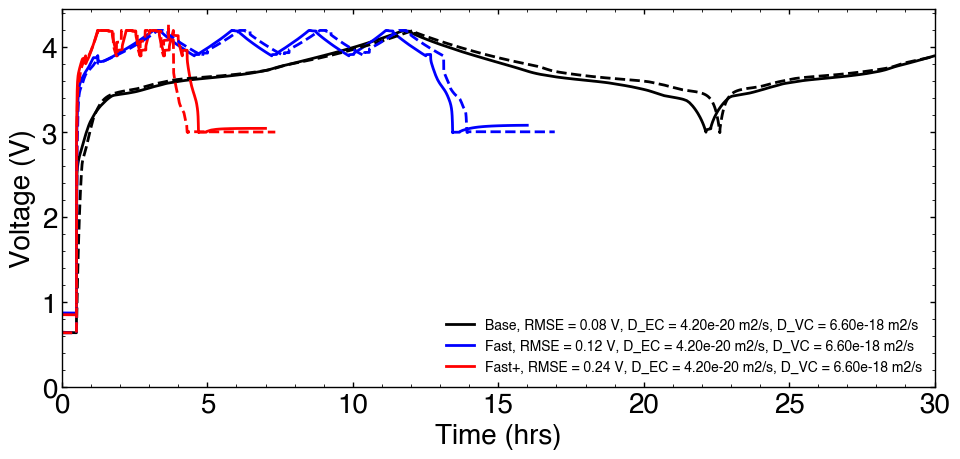

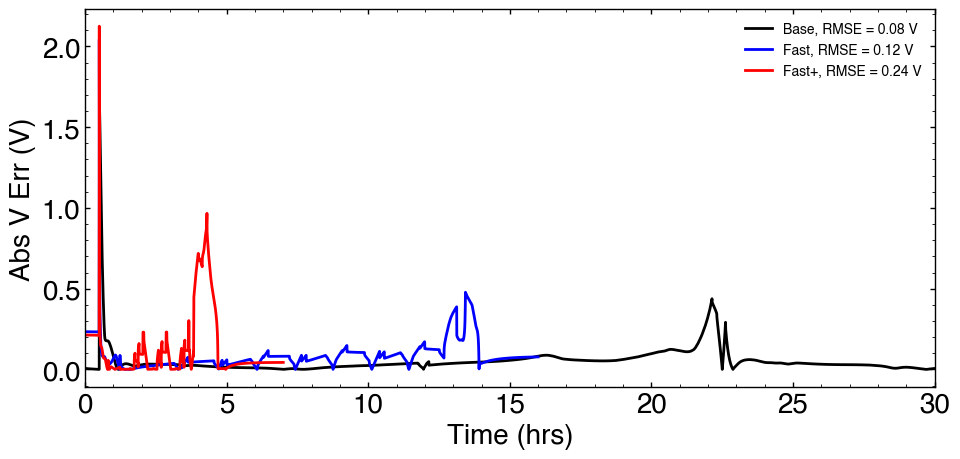

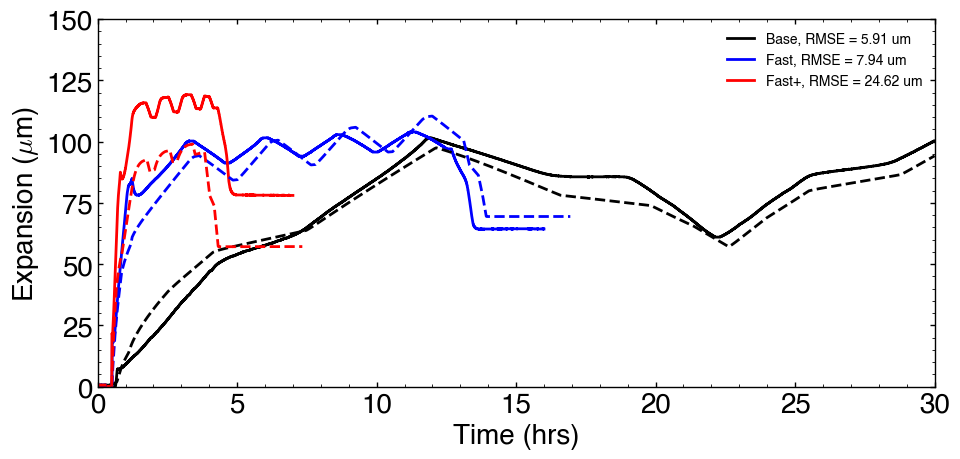

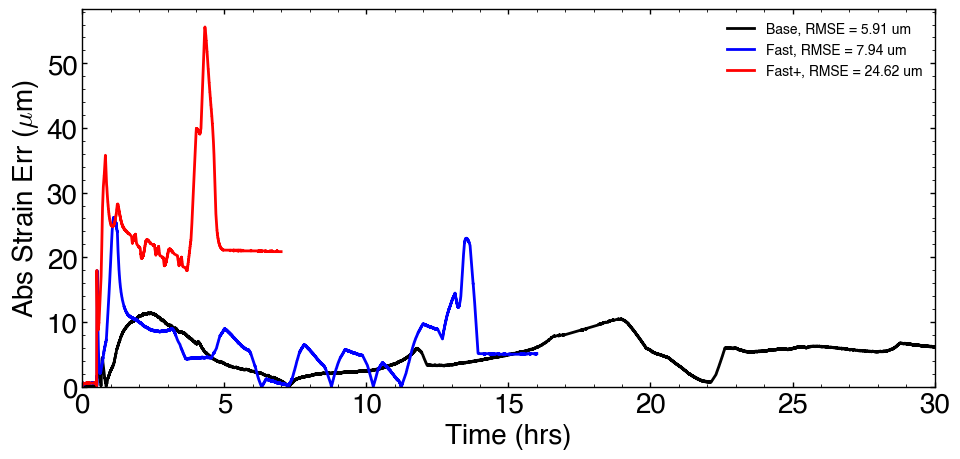

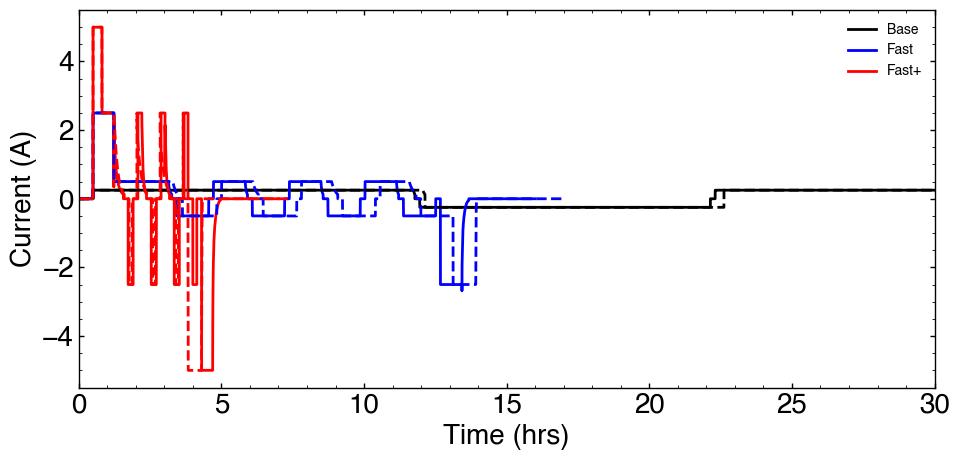

In [8]:
XLIM = (0, 30)

# Beware of experimental vs model data indexing!!
rmse1_v, tv1, sv1 = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
rmse1_e, te1, se1 = calculate_rmse(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
rmse2_v, tv2, sv2 = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
rmse2_e, te2, se2 = calculate_rmse(expt3['daq_time'], expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
rmse3_v, tv3, sv3 = calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
rmse3_e, te3, se3 = calculate_rmse(expt4['daq_time'], expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

# The voltage plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label=f'Base, RMSE = {rmse1_v:.2f} V, D_EC = {diff_ec:.2e} m2/s, D_VC = {diff_vc:.2e} m2/s')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V, D_EC = {diff_ec:.2e} m2/s, D_VC = {diff_vc:.2e} m2/s')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V, D_EC = {diff_ec:.2e} m2/s, D_VC = {diff_vc:.2e} m2/s')
ax.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# The voltage error plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(tv1/3600, sv1, color='k', label=f'Base, RMSE = {rmse1_v:.2f} V')
ax.plot(tv2/3600, sv2, color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V')
ax.plot(tv3/3600, sv3, color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Abs V Err (V)')
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# The expansion plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label=f'Base, RMSE = {rmse1_e:.2f} um')
ax.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um')
ax.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um')
ax.plot(df_sim1['t']/3600, (df_sim1['expansion'])*1e6, color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, (df_sim2['expansion'])*1e6, color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, (df_sim3['expansion'])*1e6, color='r', ls='--', label='')
ax.legend(fontsize=10)
ax.set_ylabel(r'Expansion ($\mu$m)')
ax.set_ylim(bottom=0, top=150)
ax.set_xlabel('Time (hrs)')
ax.set_xlim(XLIM)
ax.grid(False)

# The expansion error plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(tv1/3600, se1, color='k', label=f'Base, RMSE = {rmse1_e:.2f} um')
ax.plot(tv2/3600, se2, color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um')
ax.plot(tv3/3600, se3, color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel(r'Abs Strain Err ($\mu$m)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# The current plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['i_app'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['i_app'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Current (A)')
ax.legend(fontsize=10)
ax.grid(False)
ax.set_xlim(XLIM)

In [9]:
df_sim1['q_sei'].iloc[-1]

np.float64(0.33114064970477197)

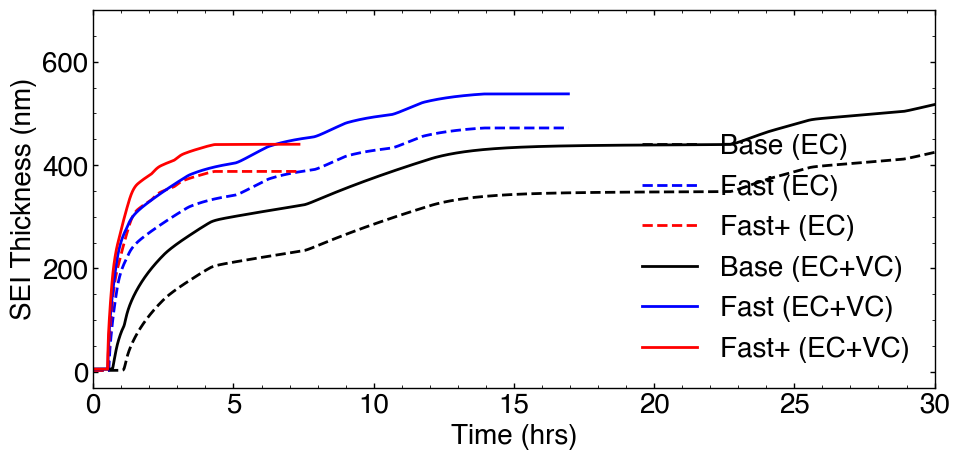

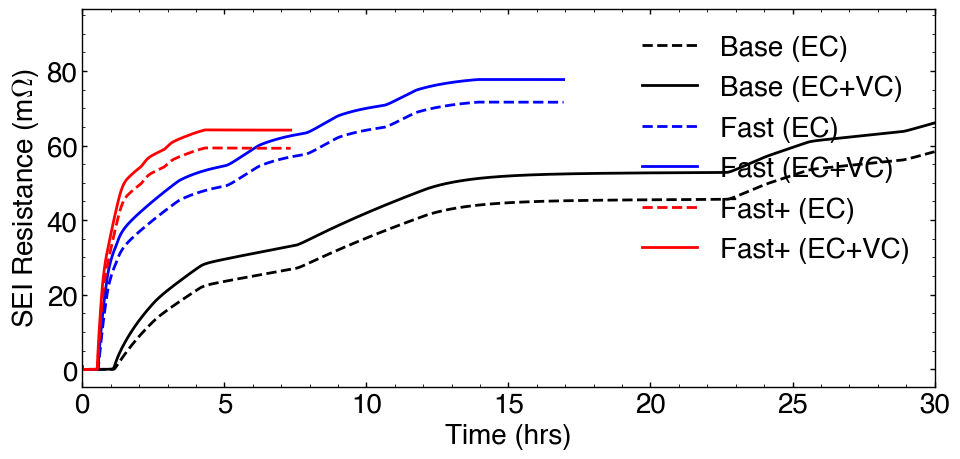

In [10]:
plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['delta_sei1']*1e9, color='k', ls='--', label='Base (EC)')
ax4.plot(df_sim2['t']/3600, df_sim2['delta_sei1']*1e9, ls='--', color='b', label='Fast (EC)')
ax4.plot(df_sim3['t']/3600, df_sim3['delta_sei1']*1e9, ls='--', color='r', label='Fast+ (EC)')
ax4.plot(df_sim1['t']/3600, (df_sim1['delta_sei'])*1e9, color='k', ls='-', label='Base (EC+VC)')
ax4.plot(df_sim2['t']/3600, (df_sim2['delta_sei'])*1e9, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3['t']/3600, (df_sim3['delta_sei'])*1e9, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel('SEI Thickness (nm)')
ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)
ax2 = plt.gca()


plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei1']*1000, color='k', label='Base (EC)', ls='--')
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei']*1000, color='k', label='Base (EC+VC)', ls='-')
ax4.plot(df_sim2['t']/3600, df_sim2['R_sei1']*1000, color='b', ls='--', label='Fast (EC)')
ax4.plot(df_sim2['t']/3600, df_sim2['R_sei']*1000, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3['t']/3600, df_sim3['R_sei1']*1000, color='r', ls='--', label='Fast+ (EC)')
ax4.plot(df_sim3['t']/3600, df_sim3['R_sei']*1000, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel(r'SEI Resistance (m$\Omega$)')

ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)

In [11]:
# Create a table comparing SEI growth across different protocols
df_result = pd.DataFrame()

# Create column headers for different time points
time_points = ['2 hrs', 'After Formation Cycles']

protocols = []
total_sei = []
vc_pcts = []
D_sei1 = []
D_sei2 = []

 # Base formation (sim1)
for t in [2*3600, sim1_time1*3600]:
    q_sei = df_sim1[df_sim1['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim1[df_sim1['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Base')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim1[df_sim1['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim1[df_sim1['t'] <= t]['D_sei2'].iloc[-1])

# Fast formation (sim2)
for t in [2*3600, sim2_time1*3600]:
    q_sei = df_sim2[df_sim2['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim2[df_sim2['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim2[df_sim2['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim2[df_sim2['t'] <= t]['D_sei2'].iloc[-1])

# Fast+ formation (sim3)
for t in [2*3600, sim3_time1*3600]:
    q_sei = df_sim3[df_sim3['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim3[df_sim3['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast+')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim3[df_sim3['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim3[df_sim3['t'] <= t]['D_sei2'].iloc[-1])


df_result = pd.DataFrame({
    'Protocol': protocols,
    'Time Point': time_points * 3,
    'Total SEI (Ah)': total_sei,
    'VC SEI %': vc_pcts,
    'D_sei1': D_sei1,
    'D_sei2': D_sei2
})


print(df_result.to_string(index=False))

Protocol             Time Point  Total SEI (Ah)  VC SEI %       D_sei1       D_sei2
    Base                  2 hrs        0.111791 56.431751 9.561239e-20 9.561239e-20
    Base After Formation Cycles        0.331141 21.279427 5.326165e-20 5.326165e-20
    Fast                  2 hrs        0.165742 26.251272 5.682142e-20 5.682142e-20
    Fast After Formation Cycles        0.263104 18.244011 5.129954e-20 5.129954e-20
   Fast+                  2 hrs        0.186117 19.395429 5.202656e-20 5.202656e-20
   Fast+ After Formation Cycles        0.214427 17.661524 5.093943e-20 5.093943e-20


In [ ]:
nn = 25
diff_ec_vec = np.logspace(-21, -18, nn)
diff_vc_vec = np.logspace(-20, -13, nn)

rmse1_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse1_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

expan1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

resistance1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
resistance2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))   
resistance3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

for i, diff_ec in enumerate(diff_ec_vec):
    for j, diff_vc in enumerate(diff_vc_vec):

        print(f'Running simulation with D_EC = {diff_ec:.2e} m2/s and D_VC = {diff_vc:.2e} m2/s')

        try:
            df_sim1 = run_sim('base', diff_ec, diff_vc)
            df_sim2 = run_sim('fast', diff_ec, diff_vc)
            df_sim3 = run_sim('fast+', diff_ec, diff_vc)
        except:
            continue

        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
        rmse1_e, _, _ = calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
        rmse2_v, _, _ = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
        rmse2_e, _, _ = calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
        rmse3_v, _, _ = calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
        rmse3_e, _, _ = calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

Running simulation with D_EC = 1.00e-21 m2/s and D_VC = 1.00e-20 m2/s
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hou

In [ ]:
# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)


/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/1969102938.py:24: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm1 = ax1.pcolormesh(X, Y, qsei1_vc_mat, shading='auto', cmap=cmap)
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/1969102938.py:29: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm2 = ax2.pcolormesh(X, Y, qsei2_vc_mat, shading='auto', cmap=cmap)
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/1969102938.py:34: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm3 = ax3.pcolormesh(X, Y, qsei3_vc_mat, shading='auto', cmap=c

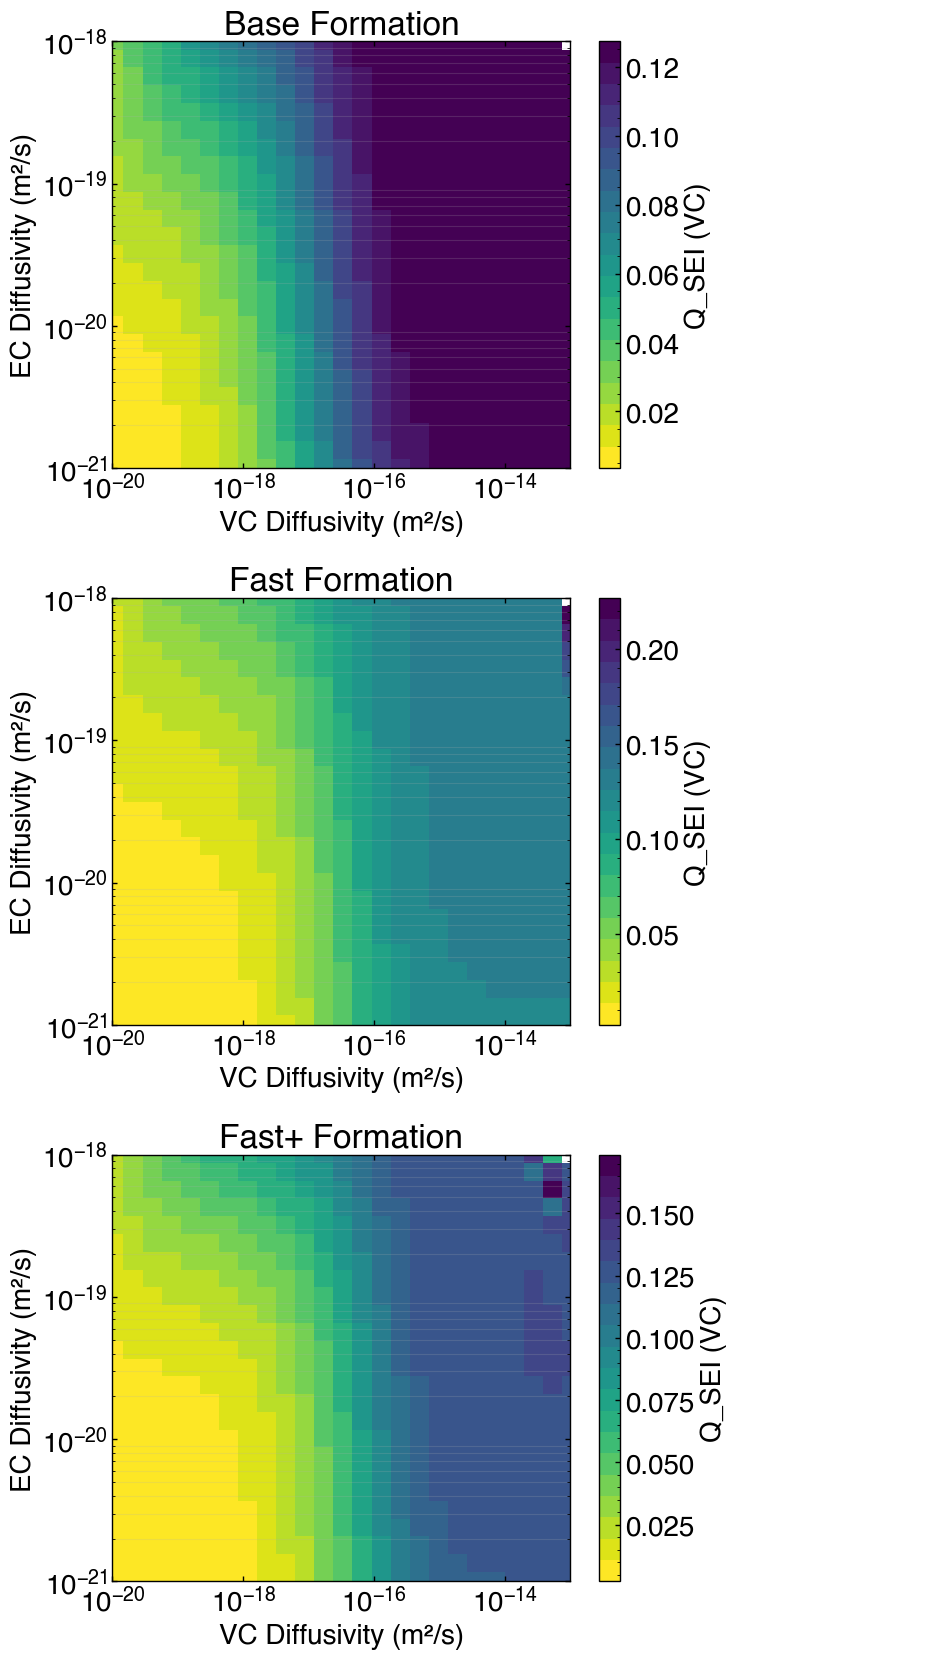

In [ ]:
nn = 25
diff_ec_vec = np.logspace(-21, -18, nn)
diff_vc_vec = np.logspace(-20, -13, nn)

#  Create a meshgrid for X and Y axes
X, Y = np.meshgrid(diff_vc_vec, diff_ec_vec)

# Create subplots for the three formation protocols
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 17))
[ax.set_xlim([min(diff_vc_vec), max(diff_vc_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_ylim([min(diff_ec_vec), max(diff_ec_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_xscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_yscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_xlabel('VC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.set_ylabel('EC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.grid(True, which="both", ls="-", alpha=0.2) for ax in (ax1, ax2, ax3)]
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get the colormap and create a discrete version with 10 bins
cmap = cm.get_cmap('viridis_r', 20)

# Base Formation
pcm1 = ax1.pcolormesh(X, Y, qsei1_vc_mat, shading='auto', cmap=cmap)
plt.colorbar(pcm1, ax=ax1, label='Q_SEI (VC)')
ax1.set_title('Base Formation')

# Fast Formation
pcm2 = ax2.pcolormesh(X, Y, qsei2_vc_mat, shading='auto', cmap=cmap)
plt.colorbar(pcm2, ax=ax2, label='Q_SEI (VC)')
ax2.set_title('Fast Formation')

# Fast+ Formation
pcm3 = ax3.pcolormesh(X, Y, qsei3_vc_mat, shading='auto', cmap=cmap)
plt.colorbar(pcm3, ax=ax3, label='Q_SEI (VC)')
ax3.set_title('Fast+ Formation')

[ax.legend(bbox_to_anchor=(1.8, 1), fontsize=14) for ax in (ax1, ax2, ax3)]
plt.tight_layout()

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/498634857.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm1 = ax1.pcolormesh(X, Y, qsei1_mat, shading='auto', cmap=cmap)
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/498634857.py:25: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm2 = ax2.pcolormesh(X, Y, qsei2_mat, shading='auto', cmap=cmap)
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/498634857.py:30: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm3 = ax3.pcolormesh(X, Y, qsei3_mat, shading='auto', cmap=cmap)
No arti

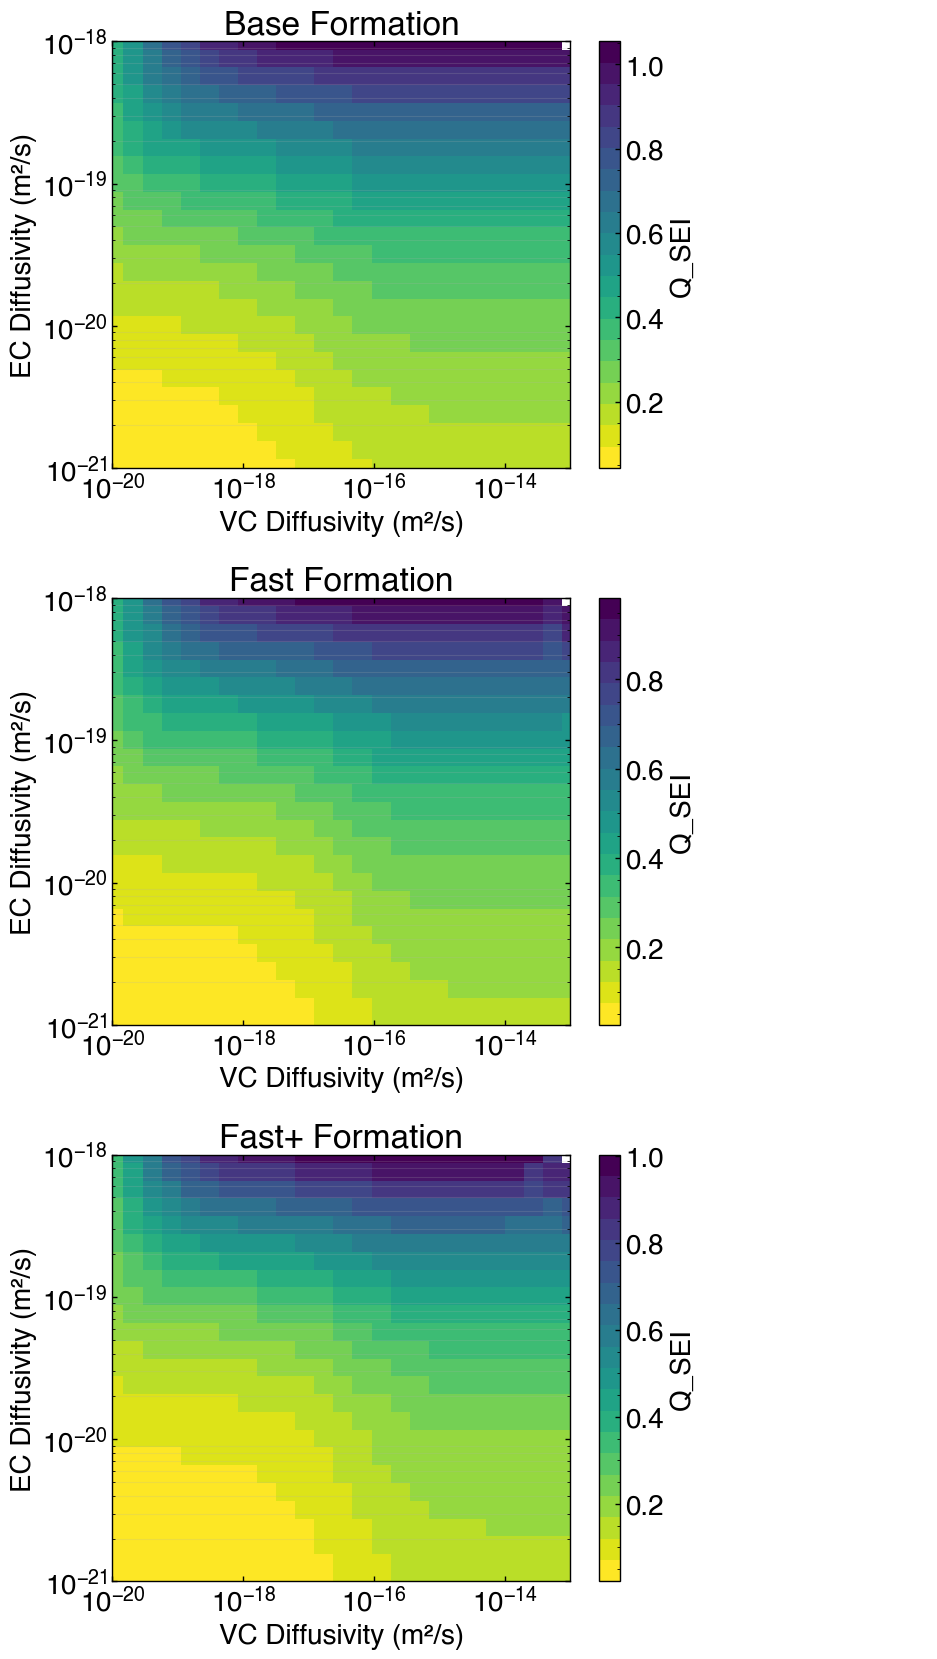

In [ ]:
# Create a meshgrid for X and Y axes
X, Y = np.meshgrid(diff_vc_vec, diff_ec_vec)

# Create subplots for the three formation protocols
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 17))
[ax.set_xlim([min(diff_vc_vec), max(diff_vc_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_ylim([min(diff_ec_vec), max(diff_ec_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_xscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_yscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_xlabel('VC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.set_ylabel('EC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.grid(True, which="both", ls="-", alpha=0.2) for ax in (ax1, ax2, ax3)]
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get the colormap and create a discrete version with 10 bins
cmap = cm.get_cmap('viridis_r', 20)

# Base Formation
pcm1 = ax1.pcolormesh(X, Y, qsei1_mat, shading='auto', cmap=cmap)
plt.colorbar(pcm1, ax=ax1, label='Q_SEI')
ax1.set_title('Base Formation')

# Fast Formation
pcm2 = ax2.pcolormesh(X, Y, qsei2_mat, shading='auto', cmap=cmap)
plt.colorbar(pcm2, ax=ax2, label='Q_SEI')
ax2.set_title('Fast Formation')

# Fast+ Formation
pcm3 = ax3.pcolormesh(X, Y, qsei3_mat, shading='auto', cmap=cmap)
plt.colorbar(pcm3, ax=ax3, label='Q_SEI')
ax3.set_title('Fast+ Formation')

[ax.legend(bbox_to_anchor=(1.8, 1), fontsize=14) for ax in (ax1, ax2, ax3)]
plt.tight_layout()

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/3665979372.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm1 = ax1.pcolormesh(X, Y, combined_rmse1, shading='auto', cmap=cmap)
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/3665979372.py:28: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm2 = ax2.pcolormesh(X, Y, combined_rmse2, shading='auto', cmap=cmap)
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/3665979372.py:37: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm3 = ax3.pcolormesh(X, Y, combined_rmse3, shading='auto', 

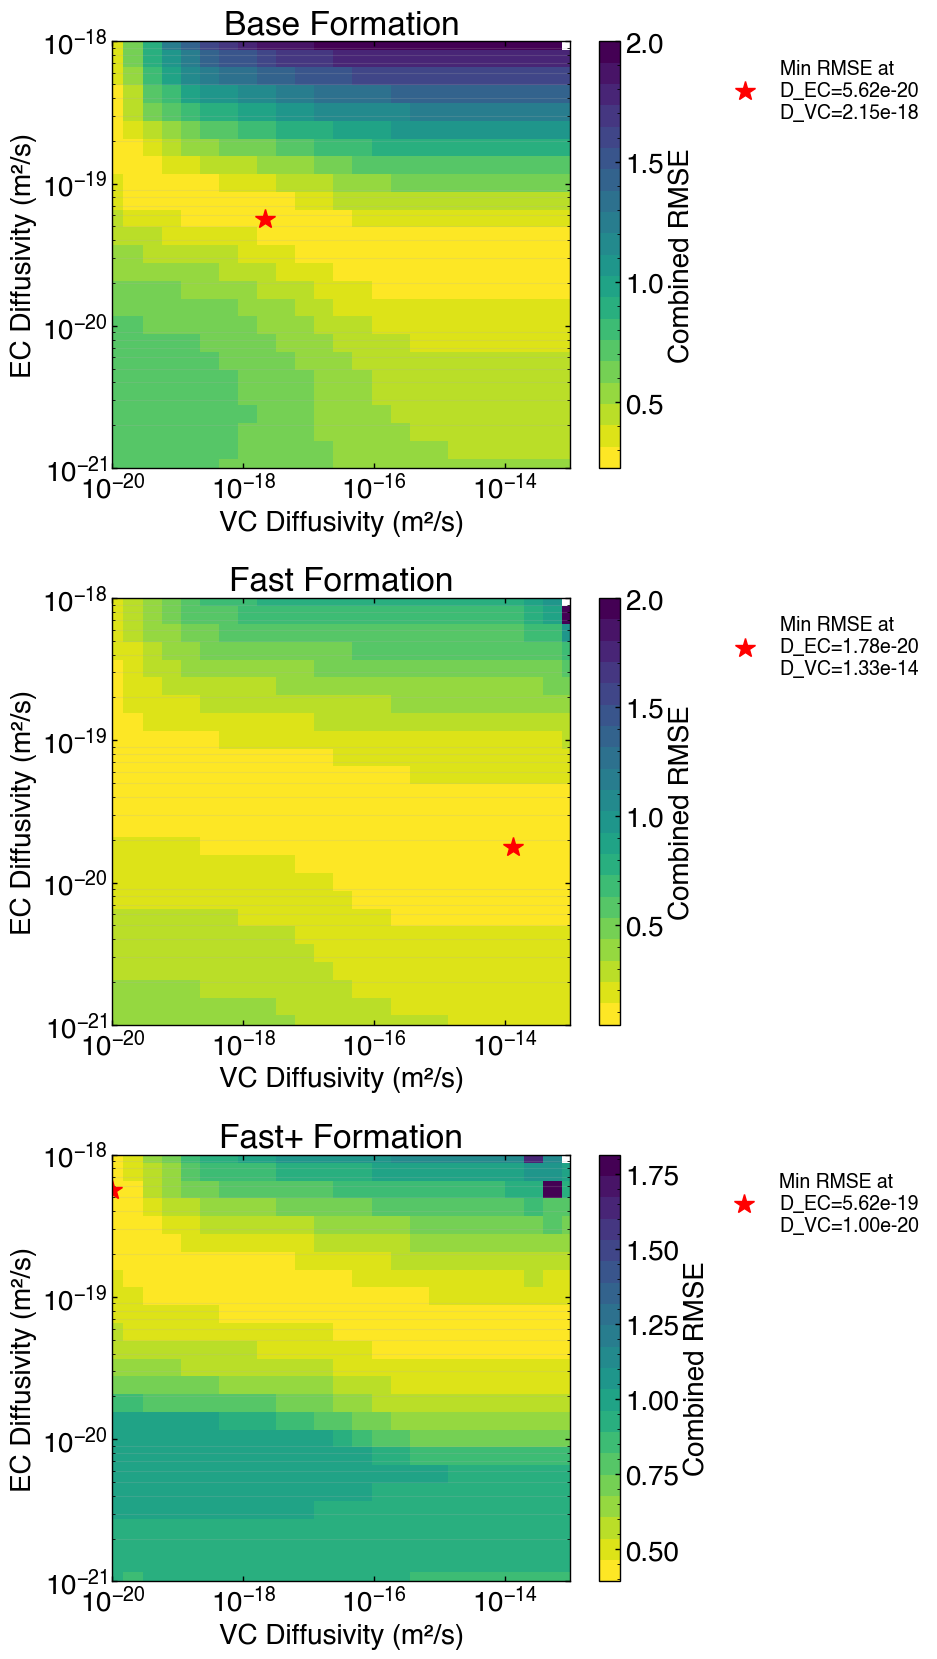

In [ ]:
# Create a meshgrid for X and Y axes
X, Y = np.meshgrid(diff_vc_vec, diff_ec_vec)

# Create subplots for the three formation protocols
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 17))
[ax.set_xlim([min(diff_vc_vec), max(diff_vc_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_ylim([min(diff_ec_vec), max(diff_ec_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_xscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_yscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_xlabel('VC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.set_ylabel('EC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.grid(True, which="both", ls="-", alpha=0.2) for ax in (ax1, ax2, ax3)]
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get the colormap and create a discrete version with 10 bins
cmap = cm.get_cmap('viridis_r', 20)

# Base Formation
pcm1 = ax1.pcolormesh(X, Y, combined_rmse1, shading='auto', cmap=cmap)
i, j = np.unravel_index(np.nanargmin(combined_rmse1), combined_rmse1.shape)
ax1.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
plt.colorbar(pcm1, ax=ax1, label='Combined RMSE')
ax1.set_title('Base Formation')

# Fast Formation
pcm2 = ax2.pcolormesh(X, Y, combined_rmse2, shading='auto', cmap=cmap)
plt.colorbar(pcm2, ax=ax2, label='Combined RMSE')
# Find the minimum point coordinates
i, j = np.unravel_index(np.nanargmin(combined_rmse2), combined_rmse2.shape)
ax2.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
ax2.set_title('Fast Formation')

# Fast+ Formation
pcm3 = ax3.pcolormesh(X, Y, combined_rmse3, shading='auto', cmap=cmap)
plt.colorbar(pcm3, ax=ax3, label='Combined RMSE')
# Find the minimum point coordinates
i, j = np.unravel_index(np.nanargmin(combined_rmse3), combined_rmse3.shape)
ax3.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
ax3.set_title('Fast+ Formation')

[ax.legend(bbox_to_anchor=(1.8, 1), fontsize=14) for ax in (ax1, ax2, ax3)]
plt.tight_layout()

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/1572337093.py:15: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm1 = ax1.pcolormesh(X, Y, rmse1_e_mat, shading='auto', cmap='viridis_r')
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/1572337093.py:25: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm2 = ax2.pcolormesh(X, Y, rmse2_e_mat, shading='auto', cmap='viridis_r')
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/1572337093.py:34: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm3 = ax3.pcolormesh(X, Y, rmse3_e_mat, shading='au

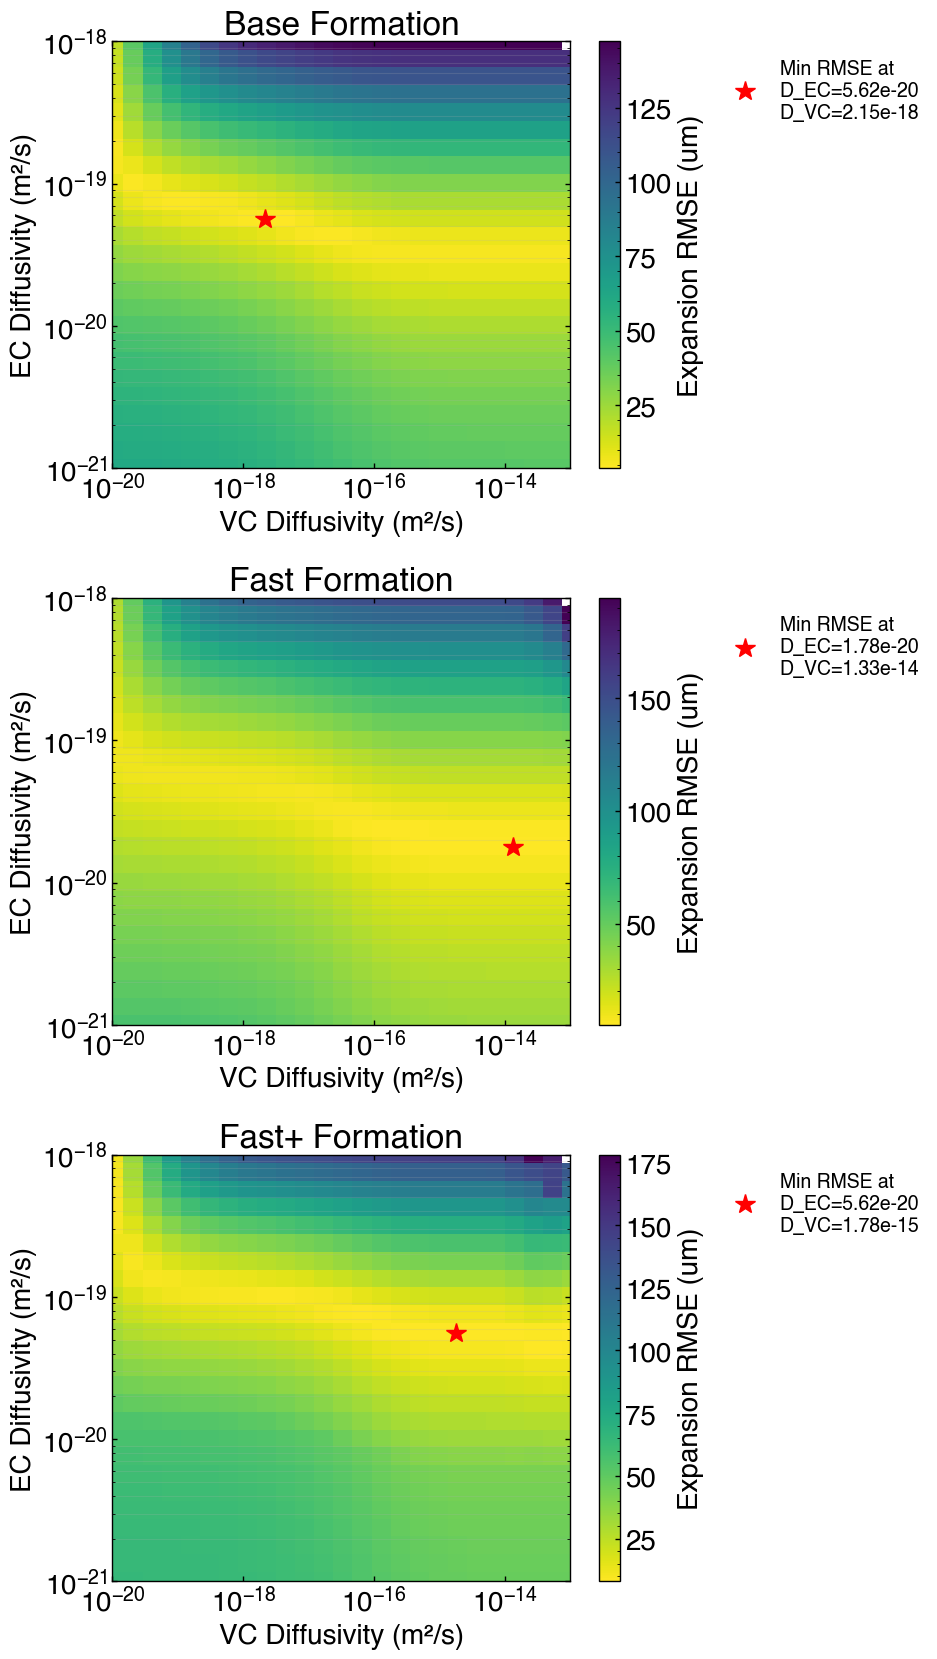

In [ ]:
# Create a meshgrid for X and Y axes
X, Y = np.meshgrid(diff_vc_vec, diff_ec_vec)

# Create subplots for the three formation protocols
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 17))
[ax.set_xlim([min(diff_vc_vec), max(diff_vc_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_ylim([min(diff_ec_vec), max(diff_ec_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_xscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_yscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_xlabel('VC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.set_ylabel('EC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.grid(True, which="both", ls="-", alpha=0.2) for ax in (ax1, ax2, ax3)]

# Base Formation
pcm1 = ax1.pcolormesh(X, Y, rmse1_e_mat, shading='auto', cmap='viridis_r')
# Find the minimum point coordinates
i, j = np.unravel_index(np.nanargmin(rmse1_e_mat), rmse1_e_mat.shape)
ax1.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')

plt.colorbar(pcm1, ax=ax1, label='Expansion RMSE (um)')
ax1.set_title('Base Formation')

# Fast Formation
pcm2 = ax2.pcolormesh(X, Y, rmse2_e_mat, shading='auto', cmap='viridis_r')
plt.colorbar(pcm2, ax=ax2, label='Expansion RMSE (um)')
# Find the minimum point coordinates
i, j = np.unravel_index(np.nanargmin(rmse2_e_mat), rmse2_e_mat.shape)
ax2.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
ax2.set_title('Fast Formation')

# Fast+ Formation
pcm3 = ax3.pcolormesh(X, Y, rmse3_e_mat, shading='auto', cmap='viridis_r')
plt.colorbar(pcm3, ax=ax3, label='Expansion RMSE (um)')
# Find the minimum point coordinates
i, j = np.unravel_index(np.nanargmin(rmse3_e_mat), rmse3_e_mat.shape)
ax3.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
ax3.set_title('Fast+ Formation')

[ax.legend(bbox_to_anchor=(1.8, 1), fontsize=14) for ax in (ax1, ax2, ax3)]
plt.tight_layout()

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/2669300158.py:15: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm1 = ax1.pcolormesh(X, Y, rmse1_v_mat, shading='auto', cmap='viridis_r')
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/2669300158.py:25: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm2 = ax2.pcolormesh(X, Y, rmse2_v_mat, shading='auto', cmap='viridis_r')
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_3114/2669300158.py:34: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pcm3 = ax3.pcolormesh(X, Y, rmse3_v_mat, shading='au

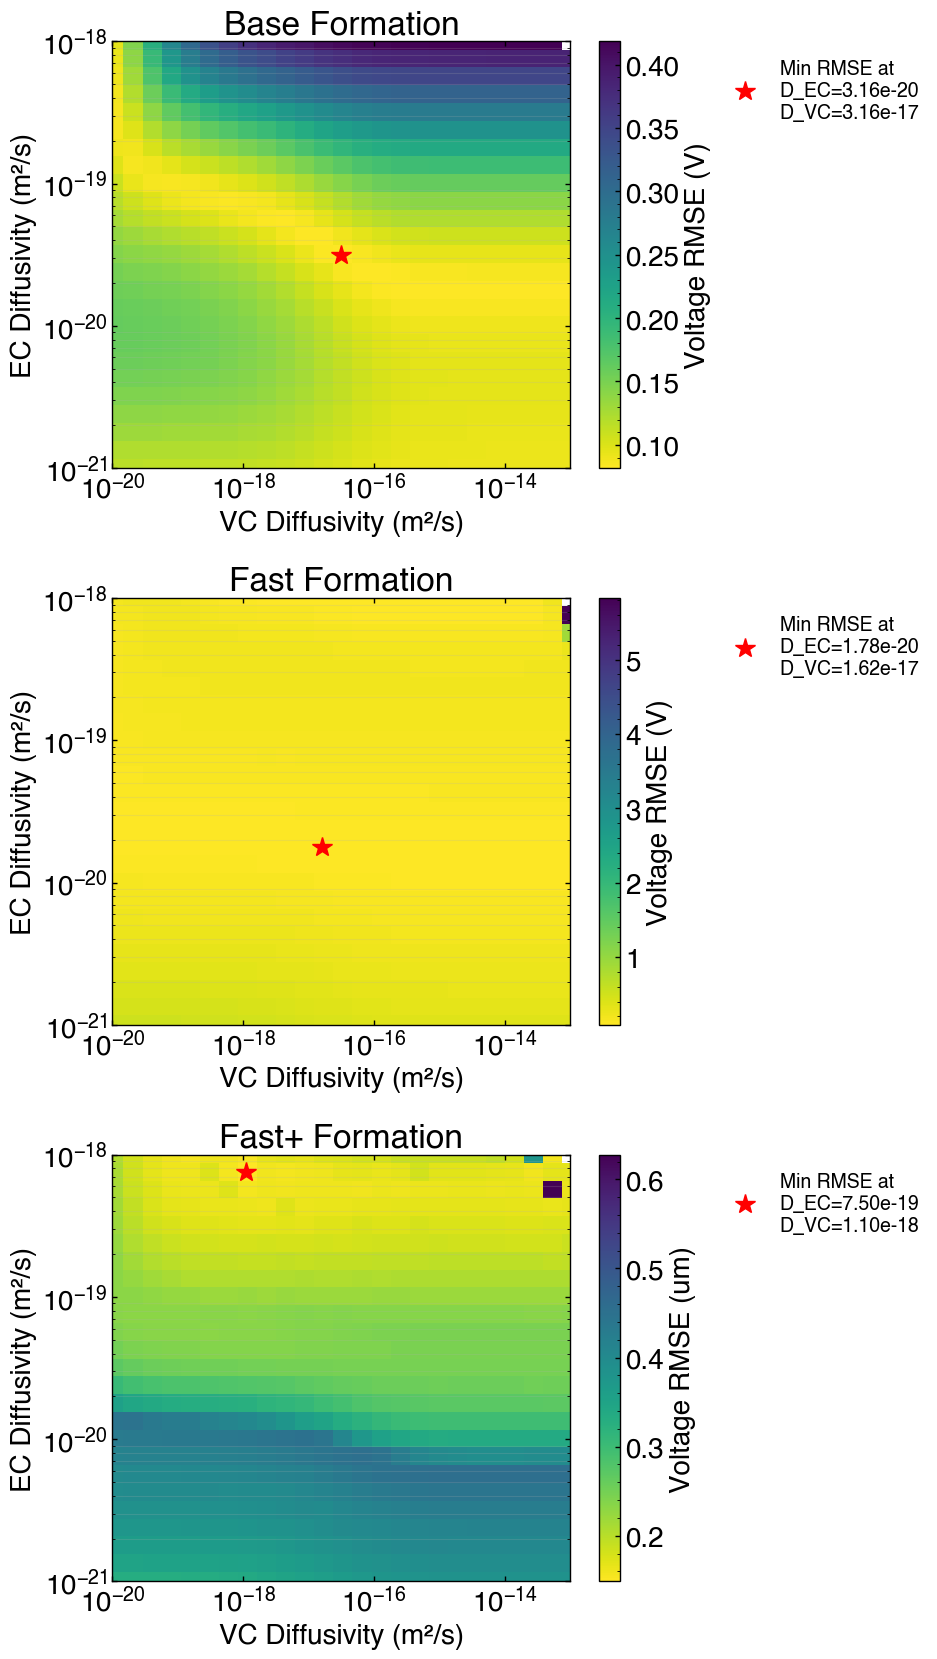

In [ ]:
# Create a meshgrid for X and Y axes
X, Y = np.meshgrid(diff_vc_vec, diff_ec_vec)

# Create subplots for the three formation protocols
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 17))
[ax.set_xlim([min(diff_vc_vec), max(diff_vc_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_ylim([min(diff_ec_vec), max(diff_ec_vec)]) for ax in (ax1, ax2, ax3)]
[ax.set_xscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_yscale('log') for ax in (ax1, ax2, ax3)]
[ax.set_xlabel('VC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.set_ylabel('EC Diffusivity (m²/s)') for ax in (ax1, ax2, ax3)]
[ax.grid(True, which="both", ls="-", alpha=0.2) for ax in (ax1, ax2, ax3)]

# Base Formation
pcm1 = ax1.pcolormesh(X, Y, rmse1_v_mat, shading='auto', cmap='viridis_r')
# Find the minimum point coordinates
i, j = np.unravel_index(np.nanargmin(rmse1_v_mat), rmse1_v_mat.shape)
ax1.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')

plt.colorbar(pcm1, ax=ax1, label='Voltage RMSE (V)')
ax1.set_title('Base Formation')

# Fast Formation
pcm2 = ax2.pcolormesh(X, Y, rmse2_v_mat, shading='auto', cmap='viridis_r')
plt.colorbar(pcm2, ax=ax2, label='Voltage RMSE (V)')
# Find the minimum point coordinates
i, j = np.unravel_index(np.nanargmin(rmse2_v_mat), rmse2_v_mat.shape)
ax2.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
ax2.set_title('Fast Formation')

# Fast+ Formation
pcm3 = ax3.pcolormesh(X, Y, rmse3_v_mat, shading='auto', cmap='viridis_r')
plt.colorbar(pcm3, ax=ax3, label='Voltage RMSE (um)')
# Find the minimum point coordinates
i, j = np.unravel_index(np.nanargmin(rmse3_v_mat), rmse3_v_mat.shape)
ax3.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
         label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
ax3.set_title('Fast+ Formation')

[ax.legend(bbox_to_anchor=(1.8, 1), fontsize=14) for ax in (ax1, ax2, ax3)]
plt.tight_layout()

In [ ]:
diff_ec_vec = np.logspace(-21, -18, 40)
diff_vc_vec = np.logspace(-20, -13, 5)
rmse1_e_vec = []
rmse1_v_vec = []
rmse2_e_vec = []
rmse2_v_vec = []
rmse3_e_vec = []
rmse3_v_vec = []

for diff_ec in diff_ec_vec:

    print(f'Running simulation with diffusivity {diff_ec:.2e} m2/s')

    df_sim1 = run_sim('base', diff_ec, diff_vc)
    df_sim2 = run_sim('fast', diff_ec, diff_vc)
    df_sim3 = run_sim('fast+', diff_ec, diff_vc)

    # Beware of experimental vs model data indexing!!
    rmse1_v, _, _ = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
    rmse1_e, _, _ = calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
    rmse2_v, _, _ = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
    rmse2_e, _, _ = calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
    rmse3_v, _, _ = calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
    rmse3_e, _, _ = calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

    rmse1_v_vec.append(rmse1_v)
    rmse1_e_vec.append(rmse1_e)
    rmse2_v_vec.append(rmse2_v)
    rmse2_e_vec.append(rmse2_e)
    rmse3_v_vec.append(rmse3_v)
    rmse3_e_vec.append(rmse3_e)

rmse1_e_vec = np.array(rmse1_e_vec)
rmse1_v_vec = np.array(rmse1_v_vec)
rmse2_e_vec = np.array(rmse2_e_vec)
rmse2_v_vec = np.array(rmse2_v_vec)
rmse3_e_vec = np.array(rmse3_e_vec)
rmse3_v_vec = np.array(rmse3_v_vec)


Running simulation with diffusivity 1.00e-21 m2/s
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: 

/Users/aweng/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: divide by zero encountered in double_scalars
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/aweng/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: divide by zero encountered in double_scalars
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])


Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running 

/Users/aweng/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: divide by zero encountered in double_scalars
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/aweng/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: divide by zero encountered in double_scalars
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/aweng/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: overflow encountered in double_scalars
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/aweng/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: overflow encountered in double_scalars
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])


Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running 

/Users/aweng/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: divide by zero encountered in double_scalars
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/aweng/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: divide by zero encountered in double_scalars
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/aweng/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: overflow encountered in double_scalars
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/aweng/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: overflow encountered in double_scalars
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])


Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running 

ValueError: stoichiometry (-0.10554961103528002) is too small.

Optimal EC diffusivity:
Base formation: 4.92e-20 m2/s
Fast formation: 2.42e-20 m2/s
Fast+ formation: 1.00e-19 m2/s


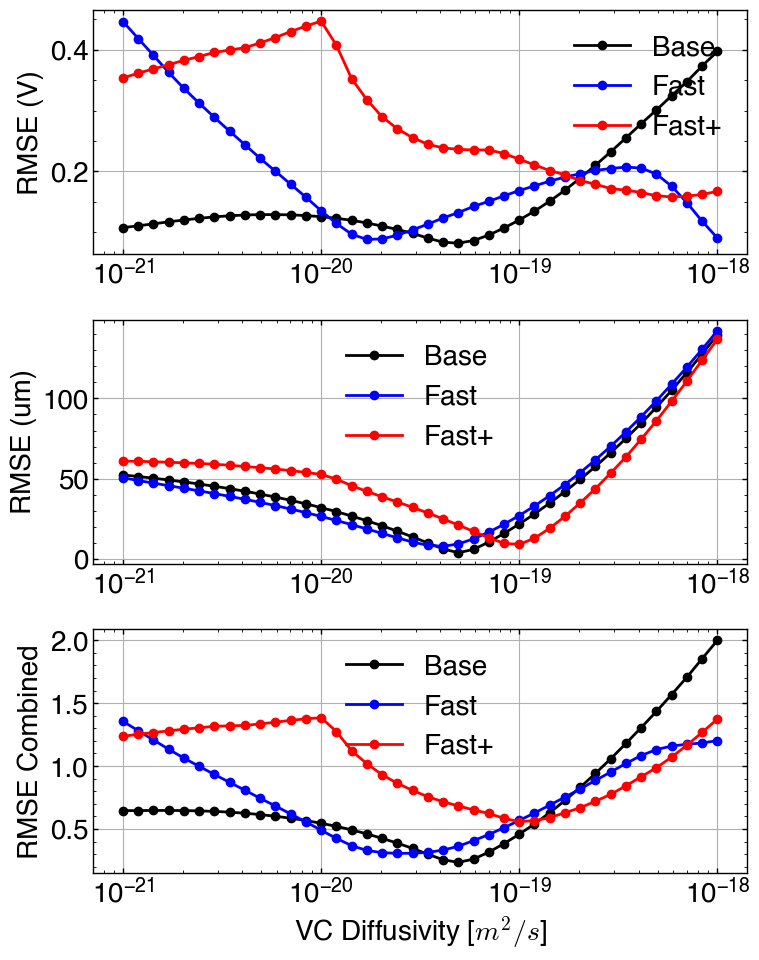

In [ ]:
combined_rmse1 = rmse1_e_vec/np.max(rmse1_e_vec) + rmse1_v_vec/np.max(rmse1_v_vec)
combined_rmse2 = rmse2_e_vec/np.max(rmse2_e_vec) + rmse2_v_vec/np.max(rmse2_v_vec)
combined_rmse3 = rmse3_e_vec/np.max(rmse3_e_vec) + rmse3_v_vec/np.max(rmse3_v_vec)

fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(8, 10))

# Plot expansion RMSE
ax1.plot(diff_ec_vec, rmse1_v_vec, c='k', marker='o', label='Base')
ax1.plot(diff_ec_vec, rmse2_v_vec, c='b', marker='o', label='Fast')
ax1.plot(diff_ec_vec, rmse3_v_vec, c='r', marker='o', label='Fast+')
ax1.set_xscale('log')
ax1.set_ylabel('RMSE (V)')
ax1.legend()

# Plot voltage RMSE
ax2.plot(diff_ec_vec, rmse1_e_vec, c='k', marker='o', label='Base')
ax2.plot(diff_ec_vec, rmse2_e_vec, c='b', marker='o', label='Fast')
ax2.plot(diff_ec_vec, rmse3_e_vec, c='r', marker='o', label='Fast+')
ax2.set_xscale('log')
ax2.set_ylabel('RMSE (um)')
ax2.legend()

# Plot combined error
ax3.plot(diff_ec_vec, combined_rmse1, c='k', marker='o', label='Base')
ax3.plot(diff_ec_vec, combined_rmse2, c='b', marker='o', label='Fast')
ax3.plot(diff_ec_vec, combined_rmse3, c='r', marker='o', label='Fast+')
ax3.set_xscale('log')
ax3.set_xlabel('VC Diffusivity [$m^2/s$]')
ax3.set_ylabel('RMSE Combined')
ax3.legend()

# Find minimum of combined error and corresponding diffusivity for each protocol
min_idx1 = np.argmin(combined_rmse1)
min_idx2 = np.argmin(combined_rmse2)
min_idx3 = np.argmin(combined_rmse3)

# Extract the optimal diffusivity values
diff1 = diff_ec_vec[min_idx1]
diff2 = diff_ec_vec[min_idx2]
diff3 = diff_ec_vec[min_idx3]

plt.tight_layout()

print(f"Optimal EC diffusivity:")
print(f"Base formation: {diff1:.2e} m2/s")
print(f"Fast formation: {diff2:.2e} m2/s")
print(f"Fast+ formation: {diff3:.2e} m2/s")

# Re-run the simulations using optimal Dsei

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.

(0.0, 30.0)

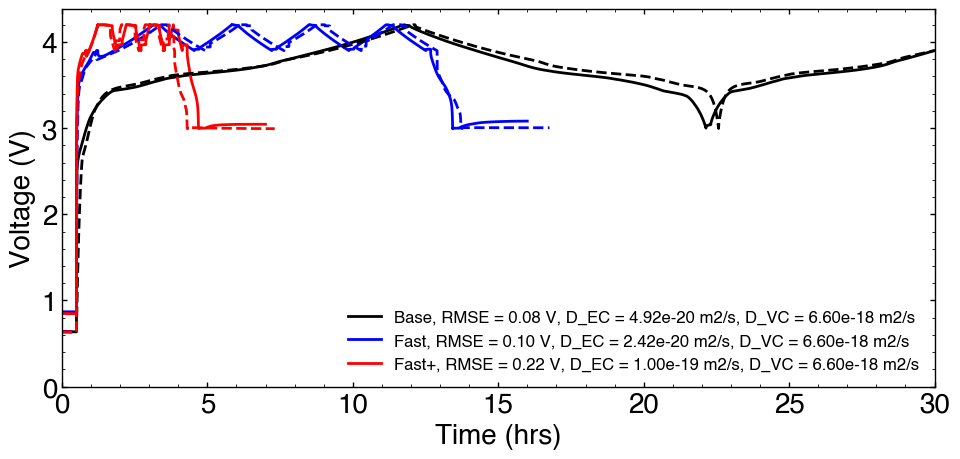

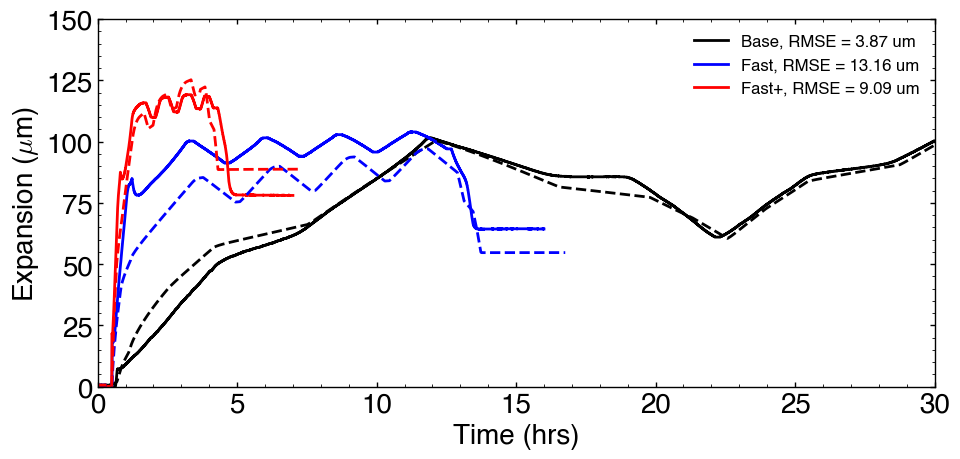

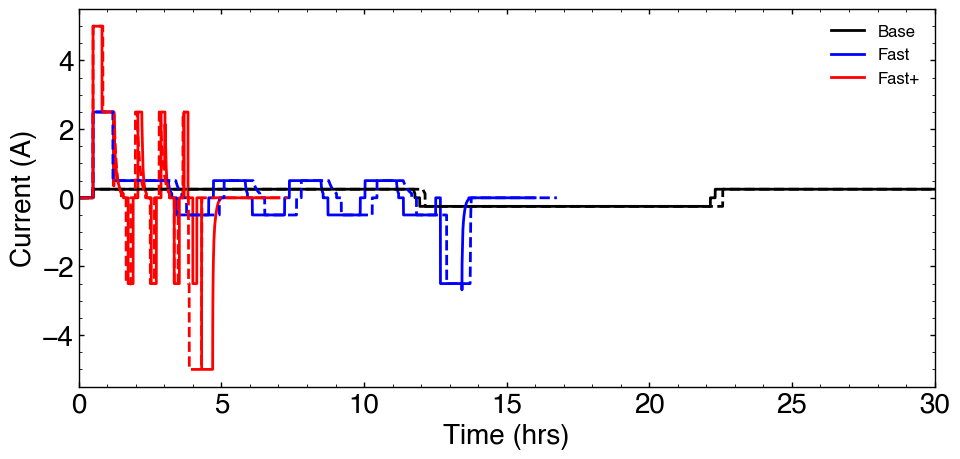

In [ ]:
df_sim1 = run_sim('base', diff1, diff_vc)
df_sim2 = run_sim('fast', diff2, diff_vc)
df_sim3 = run_sim('fast+', diff3, diff_vc)

XLIM = (0, 30)

rmse1_v, _, _ = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
rmse1_e, _, _ = calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
rmse2_v, _, _ = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
rmse2_e, _, _ = calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
rmse3_v, _, _ = calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
rmse3_e, _, _ = calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

# The voltage plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label=f'Base, RMSE = {rmse1_v:.2f} V, D_EC = {diff1:.2e} m2/s, D_VC = {diff_vc:.2e} m2/s')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V, D_EC = {diff2:.2e} m2/s, D_VC = {diff_vc:.2e} m2/s')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V, D_EC = {diff3:.2e} m2/s, D_VC = {diff_vc:.2e} m2/s')
ax.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend(fontsize=12)
ax.grid(False)

# The expansion plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label=f'Base, RMSE = {rmse1_e:.2f} um')
ax.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um')
ax.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um')
ax.plot(df_sim1['t']/3600, (df_sim1['expansion'])*1e6, color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, (df_sim2['expansion'])*1e6, color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, (df_sim3['expansion'])*1e6, color='r', ls='--', label='')
ax.legend(fontsize=12)
ax.set_ylabel(r'Expansion ($\mu$m)')
ax.set_ylim(bottom=0, top=150)
ax.set_xlabel('Time (hrs)')
ax.set_xlim(XLIM)
ax.grid(False)

# The current plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['i_app'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['i_app'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Current (A)')
ax.legend(fontsize=12)
ax.grid(False)
ax.set_xlim(XLIM)